In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Imports & Setup

In [3]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Fix random seeds for reproducibility (same as the other models)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Separate output directory prevents artifact overwrites
OUT_DIR = Path("outputs_cnn_transformer")
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete ✅")


Setup complete ✅


#Configuration
## All hyperparameters and settings are defined here in one place for easy tuning.

In [4]:
# ── File path and target — unchanged
FILE_PATH     = "/content/drive/MyDrive/Colab Notebooks/electricity_demand_srilanka_fixed.csv"
TARGET_COL    = "Load Demand (kW)"
TIMESTAMP_COL = "Timestamp"

# ── Sequence parameters — identical to CNN, LSTM, and CNN-LSTM
LOOKBACK = 96
HORIZON  = 1

# ── Chronological split ratios — identical
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# ── Training hyperparameters — identical
BATCH_SIZE = 128
MAX_EPOCHS = 50
LR         = 1e-3

# ── Transformer-only architectural settings
D_MODEL          = 64
N_HEADS          = 4
D_FF             = 256
N_BLOCKS         = 3
DROPOUT_RATE     = 0.20
LAYER_NORM_EPS   = 1e-6

assert D_MODEL % N_HEADS == 0, "D_MODEL must be divisible by N_HEADS"


# Load Data

The CSV is parsed and sorted chronologically. The full dataset is retained, exactly as in the comparison notebooks.


In [5]:
# ── Load CSV and parse timestamps
df = pd.read_csv(FILE_PATH, parse_dates=[TIMESTAMP_COL])
df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
df = df.set_index(TIMESTAMP_COL)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df.index[0]}  →  {df.index[-1]}")
df.head(3)

Dataset shape : (189888, 16)
Date range    : 2020-01-01 00:00:00  →  2025-05-31 23:45:00


,Unnamed: 0,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Poya Day
Timestamp,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1202.4797,0
2020-01-01 00:15:00,1,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1213.1439,0
2020-01-01 00:30:00,2,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1215.3267,0


# Feature Engineering
### We create two types of features:

*   **Cyclic time features** — capture daily, weekly, and seasonal patterns using sin/cos encoding
*   **Lag features** — past load values from 24h, 48h, and 1 week ago (safe: no leakage because all lags are ≥ 24h behind the target)



In [6]:
# ── Cyclic encoding for hour, day-of-week, and month
# Using sin/cos so that e.g. hour 23 and hour 0 are "close" to each other
df["sin_hour"]  = np.sin(2 * np.pi * df["Hour of Day"] / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df["Hour of Day"] / 24)
df["sin_dow"]   = np.sin(2 * np.pi * df["Day of Week"] / 7)
df["cos_dow"]   = np.cos(2 * np.pi * df["Day of Week"] / 7)
df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)

# ── Binary weekend flag
df["is_weekend"] = (df["Day of Week"] >= 5).astype(int)

# ── Normalized year (trend signal: 0.0 = 2022, 1.0 = 2025)
df["year_norm"] = (df.index.year - 2022) / 3

# ── Lag features — all shifted ≥ 96 steps (24h) to prevent data leakage
df["load_lag_96"]  = df[TARGET_COL].shift(96)       # 24 hours ago
df["load_lag_192"] = df[TARGET_COL].shift(192)      # 48 hours ago
df["load_lag_672"] = df[TARGET_COL].shift(96 * 7)  # 1 week ago

# ── Rolling statistics anchored at 24h ago (no leakage)
df["load_mean_week"] = df[TARGET_COL].shift(96).rolling(96 * 7).mean()  # 7-day mean
df["load_std_day"]   = df[TARGET_COL].shift(96).rolling(96).std()       # 24h std

# ── Drop rows with NaN (from lag/rolling windows)
df.dropna(inplace=True)
print(f"Rows after dropna: {len(df):,}")

Rows after dropna: 189,121


In [7]:
# ── Define final feature list
FEATURE_COLS = [
    # Weather inputs
    "Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)",
    "Rainfall (mm)", "Solar Irradiance (W/m²)",
    # Time features
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "sin_month", "cos_month", "is_weekend", "year_norm",
    # Calendar events
    "Public Event", "Poya Day",
    # Lag / rolling features
    "load_lag_96", "load_lag_192", "load_lag_672",
    "load_mean_week", "load_std_day",
]

# Keep only columns that actually exist in the dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f"Total features : {len(FEATURE_COLS)}")
print(f"Feature list   : {FEATURE_COLS}")

Total features : 20
Feature list   : ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'is_weekend', 'year_norm', 'Public Event', 'Poya Day', 'load_lag_96', 'load_lag_192', 'load_lag_672', 'load_mean_week', 'load_std_day']


# Leakage Sanity Check
### We check the Pearson correlation of each feature with the target. A correlation > 0.98 would suggest the feature is almost identical to the target — a sign of data leakage.

Safe features have meaningful but not suspiciously perfect correlation.

In [8]:
print(f"{'Feature':<35}  Correlation with Target")
print("-" * 60)

for col in FEATURE_COLS:
    corr = df[col].corr(df[TARGET_COL])
    flag = "  ⚠️  POTENTIAL LEAKAGE" if abs(corr) > 0.98 else ""
    print(f"  {col:<35} {corr:+.4f}{flag}")

Feature                              Correlation with Target
------------------------------------------------------------
  Temperature (°C)                    +0.0132
  Humidity (%)                        +0.0015
  Wind Speed (m/s)                    +0.0016
  Rainfall (mm)                       -0.0024
  Solar Irradiance (W/m²)             -0.0044
  sin_hour                            +0.0636
  cos_hour                            -0.6127
  sin_dow                             +0.1589
  cos_dow                             -0.1787
  sin_month                           +0.2942
  cos_month                           -0.0485
  is_weekend                          -0.2134
  year_norm                           +0.6628
  Public Event                        -0.0642
  Poya Day                            -0.1162
  load_lag_96                         +0.9139
  load_lag_192                        +0.8584
  load_lag_672                        +0.9505
  load_mean_week                      +0.6981
  lo

# Temporal Split & Scaling
### **Important**: We use a **temporal (chronological) split** — never shuffle time-series data!


*   Train: first 70%
*   Validation: next 15%
*   Test: final 15%

Features and target are scaled **separately** with their own StandardScaler.





In [9]:
n       = len(df)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

# ── Chronological split
df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

print(f"Train : {len(df_train):,} samples  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Val   : {len(df_val):,} samples  ({df_val.index[0].date()} → {df_val.index[-1].date()})")
print(f"Test  : {len(df_test):,} samples  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

Train : 151,296 samples  (2020-01-08 → 2024-05-02)
Val   : 18,912 samples  (2024-05-02 → 2024-11-15)
Test  : 18,913 samples  (2024-11-15 → 2025-05-31)


In [10]:
# ── Fit scalers on TRAINING data only, then apply to val/test
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_tr_raw = feat_scaler.fit_transform(df_train[FEATURE_COLS])
y_tr_raw = target_scaler.fit_transform(df_train[[TARGET_COL]])

X_vl_raw = feat_scaler.transform(df_val[FEATURE_COLS])     # transform only!
y_vl_raw = target_scaler.transform(df_val[[TARGET_COL]])

X_te_raw = feat_scaler.transform(df_test[FEATURE_COLS])
y_te_raw = target_scaler.transform(df_test[[TARGET_COL]])

# ── Save scalers for future inference
joblib.dump(feat_scaler,   OUT_DIR / "feat_scaler.pkl")
joblib.dump(target_scaler, OUT_DIR / "target_scaler.pkl")

print("Scalers saved ✅")

Scalers saved ✅


# Build Sliding-Window Sequences

Each input contains `LOOKBACK=168` timesteps and each target contains the next `HORIZON=4` values.


In [11]:
def build_sequences(X, y, lookback, horizon=1):
    """
    Convert flat arrays into overlapping windows.
    X shape: (samples, lookback, features)
    y shape: (samples, horizon)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_tr, y_tr = build_sequences(X_tr_raw, y_tr_raw, LOOKBACK, HORIZON)
X_vl, y_vl = build_sequences(X_vl_raw, y_vl_raw, LOOKBACK, HORIZON)
X_te, y_te = build_sequences(X_te_raw, y_te_raw, LOOKBACK, HORIZON)

print(f"Train  X: {X_tr.shape}  y: {y_tr.shape}")
print(f"Val    X: {X_vl.shape}  y: {y_vl.shape}")
print(f"Test   X: {X_te.shape}  y: {y_te.shape}")

# ── Quick check: make sure target is not constant
assert y_tr.std() > 0.01, "❌ Target variance near zero — check sequence building!"
print(f"\nTarget stats — mean: {y_tr.mean():.4f}  std: {y_tr.std():.4f}  ✅")

Train  X: (151200, 96, 20)  y: (151200, 1)
Val    X: (18816, 96, 20)  y: (18816, 1)
Test   X: (18817, 96, 20)  y: (18817, 1)

Target stats — mean: 0.0003  std: 1.0001  ✅


## Build the CNN-Transformer Baseline

This model combines the original causal CNN front end with the same
capacity-matched Transformer encoder used by the corrected Transformer
baseline.

```
Input(168 × 20)
→ Conv1D(64, kernel=3, causal)
→ Conv1D(32, kernel=3, causal)
→ Dense embedding(64)
→ Sinusoidal positional encoding
→ 3 Transformer encoder blocks
   → 4-head self-attention
   → Feed-forward network(256)
   → Residual connections + layer normalization
→ GlobalAveragePooling1D
→ Dense(64)
→ Dropout(0.20)
→ Output(4)
```

All non-architectural settings are identical to CNN, LSTM, CNN-LSTM, and the
corrected Transformer baseline. MC-dropout averaging and conformal calibration
are intentionally excluded because the comparison uses deterministic point
forecast evaluation for every model.


In [12]:
@tf.keras.utils.register_keras_serializable(package="LoadForecasting")
class PositionalEncoding(tf.keras.layers.Layer):
    '''Fixed sinusoidal positional encoding for temporal order information.'''

    def __init__(self, max_seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_seq_len = int(max_seq_len)
        self.d_model = int(d_model)

        position = np.arange(self.max_seq_len, dtype=np.float32)[:, np.newaxis]
        dimension = np.arange(self.d_model, dtype=np.float32)[np.newaxis, :]
        angle_rates = 1.0 / np.power(
            10000.0, (2 * np.floor(dimension / 2)) / self.d_model
        )
        angles = position * angle_rates

        encoding = np.zeros((self.max_seq_len, self.d_model), dtype=np.float32)
        encoding[:, 0::2] = np.sin(angles[:, 0::2])
        encoding[:, 1::2] = np.cos(angles[:, 1::2])
        self.positional_encoding = tf.constant(encoding[np.newaxis, :, :])

    def call(self, inputs):
        sequence_length = tf.shape(inputs)[1]
        encoding = tf.cast(
            self.positional_encoding[:, :sequence_length, :], inputs.dtype
        )
        return inputs + encoding

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_seq_len": self.max_seq_len,
            "d_model": self.d_model,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="LoadForecasting")
class TransformerBlock(tf.keras.layers.Layer):
    '''Transformer encoder block with attention and feed-forward residuals.'''

    def __init__(
        self, d_model, n_heads, d_ff, dropout_rate,
        layer_norm_eps=1e-6, **kwargs
    ):
        super().__init__(**kwargs)
        self.d_model = int(d_model)
        self.n_heads = int(n_heads)
        self.d_ff = int(d_ff)
        self.dropout_rate = float(dropout_rate)
        self.layer_norm_eps = float(layer_norm_eps)

        self.attention = MultiHeadAttention(
            num_heads=self.n_heads,
            key_dim=self.d_model // self.n_heads,
            dropout=self.dropout_rate,
        )
        self.attention_dropout = Dropout(self.dropout_rate)
        self.attention_norm = LayerNormalization(epsilon=self.layer_norm_eps)

        self.ffn_dense_1 = Dense(self.d_ff, activation="relu")
        self.ffn_dense_2 = Dense(self.d_model)
        self.ffn_dropout = Dropout(self.dropout_rate)
        self.ffn_norm = LayerNormalization(epsilon=self.layer_norm_eps)

    def call(self, inputs, training=None):
        attention_output = self.attention(
            inputs, inputs, training=training
        )
        attention_output = self.attention_dropout(
            attention_output, training=training
        )
        x = self.attention_norm(inputs + attention_output)

        ffn_output = self.ffn_dense_2(self.ffn_dense_1(x))
        ffn_output = self.ffn_dropout(ffn_output, training=training)
        return self.ffn_norm(x + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "n_heads": self.n_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
            "layer_norm_eps": self.layer_norm_eps,
        })
        return config


In [13]:
n_steps    = LOOKBACK
n_features = X_tr.shape[2]

# ── Input
inp = Input(shape=(n_steps, n_features), name="input")

# ── CNN front end: identical filters, kernel, padding, and activation
x = Conv1D(
    filters=64, kernel_size=3, padding="causal",
    activation="relu", name="conv1"
)(inp)
x = Conv1D(
    filters=32, kernel_size=3, padding="causal",
    activation="relu", name="conv2"
)(x)

# ── Project CNN output to the Transformer embedding dimension
x = Dense(D_MODEL, activation="relu", name="embedding")(x)
x = PositionalEncoding(
    max_seq_len=n_steps, d_model=D_MODEL, name="positional_encoding"
)(x)

# ── Same Transformer encoder stack as Transformer Baseline V2
for block_index in range(N_BLOCKS):
    x = TransformerBlock(
        d_model=D_MODEL,
        n_heads=N_HEADS,
        d_ff=D_FF,
        dropout_rate=DROPOUT_RATE,
        layer_norm_eps=LAYER_NORM_EPS,
        name=f"transformer_block_{block_index + 1}",
    )(x)

# ── Output block
x = GlobalAveragePooling1D(name="global_average_pooling")(x)
x = Dense(64, activation="relu", name="dense_head")(x)
x = Dropout(DROPOUT_RATE, name="output_dropout")(x)
out = Dense(HORIZON, name="forecast_output")(x)

model = Model(inp, out, name="CNN_Transformer_Forecaster")
model.compile(
    optimizer=Adam(LR),
    loss="mae",
    metrics=["mae"],
)

assert model.output_shape == (None, HORIZON)

CNN_LSTM_REFERENCE_PARAMS = 146_340
TRANSFORMER_REFERENCE_PARAMS = 155_716
print(f"CNN-Transformer parameters : {model.count_params():,}")
print(f"CNN-LSTM parameters        : {CNN_LSTM_REFERENCE_PARAMS:,} (reference)")
print(f"Transformer parameters     : {TRANSFORMER_REFERENCE_PARAMS:,} (reference)")
print(f"vs CNN-LSTM capacity ratio : {model.count_params() / CNN_LSTM_REFERENCE_PARAMS:.3f}×")
model.summary()


CNN-Transformer parameters : 166,369
CNN-LSTM parameters        : 146,340 (reference)
Transformer parameters     : 155,716 (reference)
vs CNN-LSTM capacity ratio : 1.137×


Model: "CNN_Transformer_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 96, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 96, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 96, 64)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 96, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 96, 64)         │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 96, 64)         │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 96, 64)         │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dropout (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_output (Dense)         │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,369 (649.88 KB)

 Trainable params: 166,369 (649.88 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

We use three callbacks:

| Callback | Purpose |
|----------|---------|
| `EarlyStopping` | Stop training when validation loss stops improving |
| `ReduceLROnPlateau` | Halve learning rate when stuck |
| `ModelCheckpoint` | Save the best model weights |

In [14]:
ckpt_path = str(OUT_DIR / "best_model.keras")

callbacks = [
    # Stop if val_loss doesn't improve for 15 epochs; restore best weights
    EarlyStopping(
        monitor="val_loss", patience=15,
        min_delta=1e-4, restore_best_weights=True, verbose=1
    ),
    # Reduce LR by 50% if val_loss plateaus for 8 epochs
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=8, min_lr=1e-5, verbose=1
    ),
    # Save best model to disk
    ModelCheckpoint(
        ckpt_path, monitor="val_loss",
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=False,   # must NOT shuffle time-series data!
    verbose=1,
)

Epoch 1/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 64s 31ms/step - loss: 0.2192 - mae: 0.2192 - val_loss: 0.5261 - val_mae: 0.5261 - learning_rate: 0.0010
Epoch 2/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 0.1645 - mae: 0.1645 - val_loss: 0.4390 - val_mae: 0.4390 - learning_rate: 0.0010
Epoch 3/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.1528 - mae: 0.1528 - val_loss: 0.4877 - val_mae: 0.4877 - learning_rate: 0.0010
Epoch 4/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - loss: 0.1449 - mae: 0.1449 - val_loss: 0.4149 - val_mae: 0.4149 - learning_rate: 0.0010
Epoch 5/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 0.1358 - mae: 0.1358 - val_loss: 0.4176 - val_mae: 0.4176 - learning_rate: 0.0010
Epoch 6/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.1314 - mae: 0.1314 - val_loss: 0.4068 - val_mae: 0.4068 - learning_rate: 0.0010
Epoch 7/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.1285 - mae: 0.1285 - val_loss: 0.3793 - val_mae: 0.3793 - 

## Evaluate the Model

We evaluate on all three splits using four metrics:

| Metric | Meaning |
|--------|---------|
| **MAE** | Mean Absolute Error — average error in kW |
| **RMSE** | Root Mean Squared Error — penalizes large errors more |
| **MAPE** | Mean Absolute Percentage Error — intuitive % error |
| **R²** | Coefficient of determination — 1.0 = perfect fit |

In [23]:
# ── Reload the best complete model; this also validates serialization
model = tf.keras.models.load_model(ckpt_path)


def evaluate(X, y_scaled, split_name):
    '''Predict, inverse-transform, and print metrics for a given split.'''
    pred_scaled = model.predict(X, batch_size=BATCH_SIZE, verbose=0)

    # ── Inverse-transform back to original kW scale
    y_true = target_scaler.inverse_transform(y_scaled)
    y_pred = target_scaler.inverse_transform(pred_scaled)

    # ── Warn if predictions are nearly constant (bad sign)
    if y_pred.std() < 1.0:
        print(f"  ⚠️  [{split_name}] Predictions nearly constant — model may not have learned!")

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"  {split_name:6s} → MAE={mae:.2f} kW | RMSE={rmse:.2f} kW | MAPE={mape:.2f}% | R²={r2:.4f}")
    return y_true, y_pred


print("── Evaluation Results ──")
y_tr_true, y_tr_pred = evaluate(X_tr, y_tr, "Train")
y_vl_true, y_vl_pred = evaluate(X_vl, y_vl, "Val")
y_te_true, y_te_pred = evaluate(X_te, y_te, "Test")


── Evaluation Results ──
  Train  → MAE=34.54 kW | RMSE=45.44 kW | MAPE=1.98% | R²=0.9784
  Val    → MAE=40.39 kW | RMSE=50.70 kW | MAPE=1.95% | R²=0.9532
  Test   → MAE=38.80 kW | RMSE=46.38 kW | MAPE=1.76% | R²=0.9357


## Visualize Results

Three plots:
1. **Training curves** — loss over epochs
2. **Predictions vs actuals** — 7-day window on test set
3. **Scatter plot** — predicted vs actual (closer to diagonal = better)

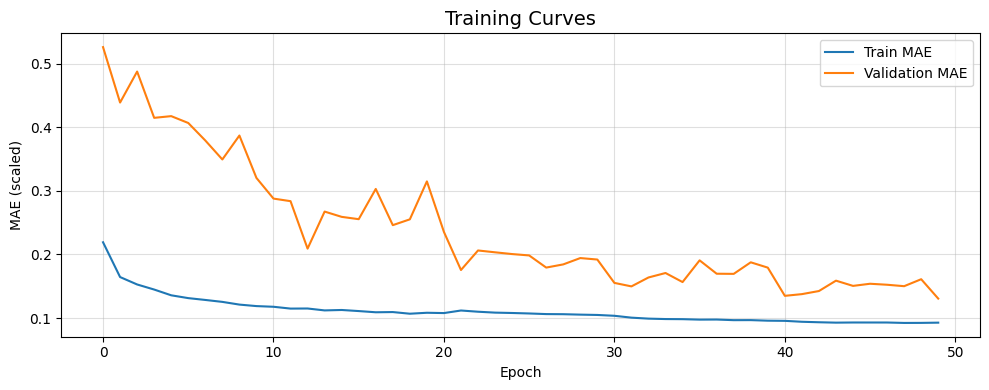

In [24]:
# ── Plot 1: Training & Validation Loss Curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"],     label="Train MAE")
ax.plot(history.history["val_loss"], label="Validation MAE")
ax.set_title("Training Curves", fontsize=14)
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (scaled)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

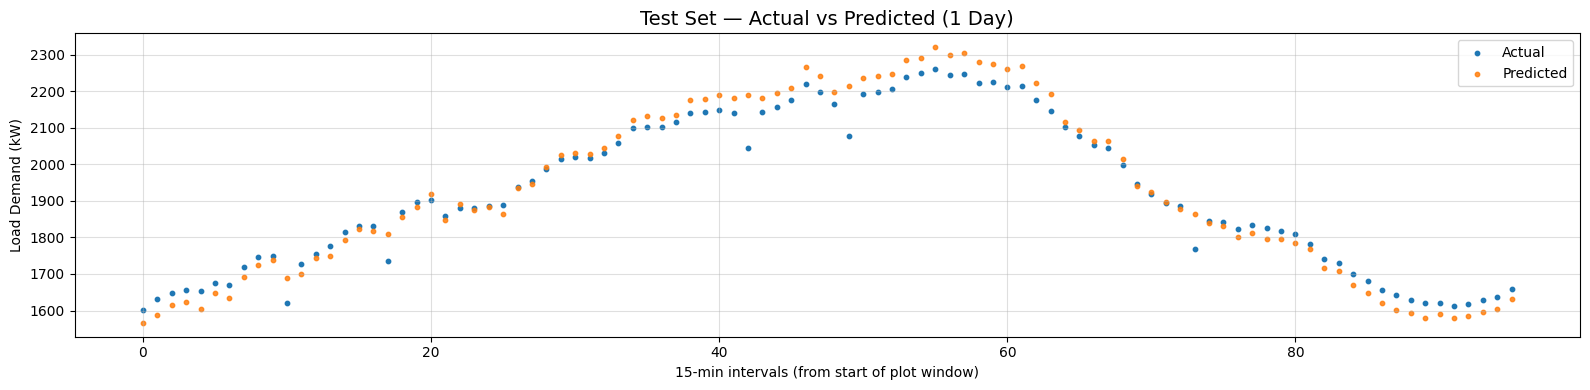

In [25]:
# ── Plot 2: Actual vs Predicted (Scatter) — 1-day window on test set
n_plot = min(4 * 24, len(y_te_true))   # 1 day of 15-min intervals

fig, ax = plt.subplots(figsize=(16, 4))
ax.scatter(range(n_plot), y_te_true[:n_plot, 0], label="Actual", s=10)
ax.scatter(range(n_plot), y_te_pred[:n_plot, 0], label="Predicted", s=10, alpha=0.85)
ax.set_title("Test Set — Actual vs Predicted (1 Day)", fontsize=14)
ax.set_xlabel("15-min intervals (from start of plot window)")
ax.set_ylabel("Load Demand (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "test_predictions_scatter.png", dpi=150)
plt.show()

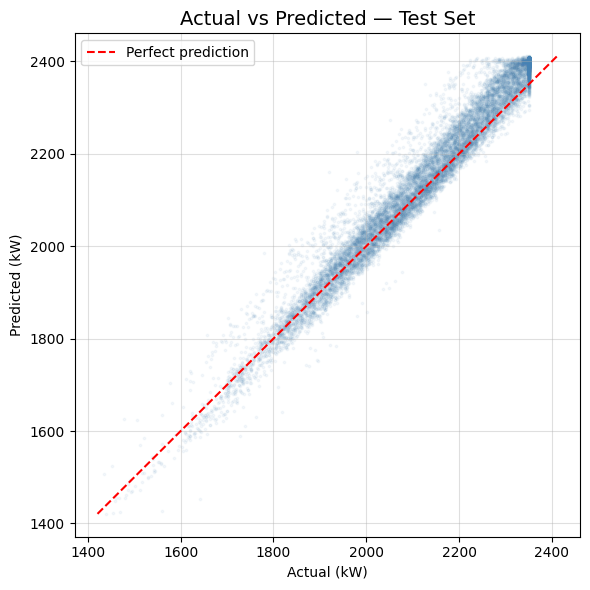

In [26]:
# ── Plot 3: Scatter — Actual vs Predicted
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te_true.flatten(), y_te_pred.flatten(),
           alpha=0.05, s=3, color="steelblue")

# Perfect prediction line
lims = [min(y_te_true.min(), y_te_pred.min()),
        max(y_te_true.max(), y_te_pred.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")

ax.set_title("Actual vs Predicted — Test Set", fontsize=14)
ax.set_xlabel("Actual (kW)")
ax.set_ylabel("Predicted (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "scatter.png", dpi=150)
plt.show()

Predicted and Actual Load Demand for a period in 2022 (from Training Data):

--- First 5 days of 2022 in the training set ---
| Timestamp           | Actual Load Demand (kW)   | Predicted Load Demand (kW)   |
|:--------------------|:--------------------------|:-----------------------------|
| 2022-01-01 00:00:00 | 1368.23                   | 1432.31                      |
| 2022-01-01 00:15:00 | 1345.85                   | 1323.52                      |
| 2022-01-01 00:30:00 | 1329.4                    | 1280.57                      |
| 2022-01-01 00:45:00 | 1359.36                   | 1314.21                      |
| 2022-01-01 01:00:00 | 1401.81                   | 1374.23                      |
| 2022-01-01 01:15:00 | 1402.17                   | 1372.69                      |
| 2022-01-01 01:30:00 | 1423.37                   | 1405.27                      |
| 2022-01-01 01:45:00 | 1441.03                   | 1418.25                      |
| 2022-01-01 02:00:00 | 1448.39             

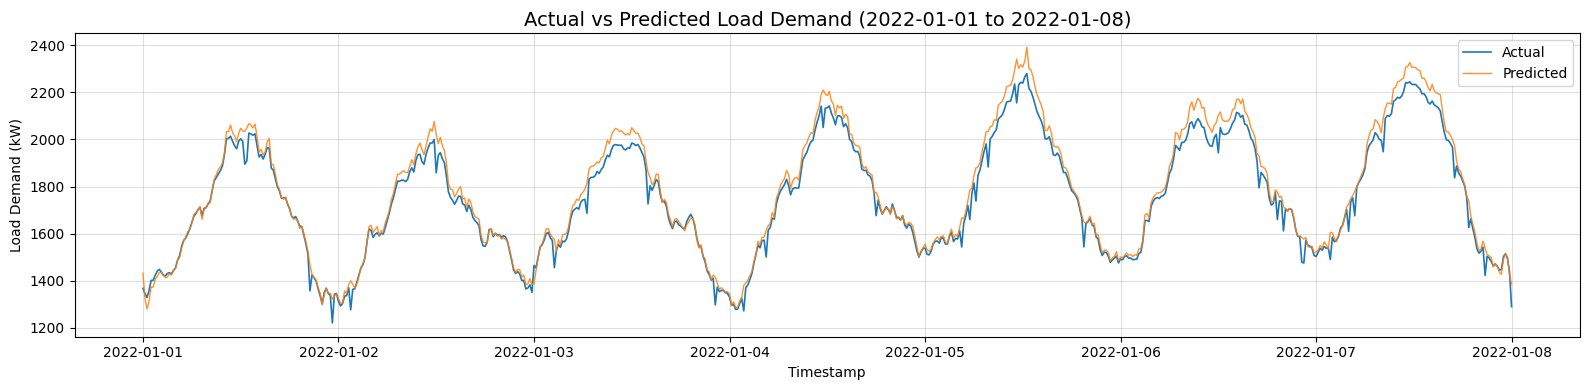

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Reconstruct the original timestamps for the training predictions
# The y_tr_true and y_tr_pred arrays correspond to the target values from
# df_train starting after the LOOKBACK period.
# The index for these predictions should be from df_train starting at LOOKBACK for the first forecast horizon
start_idx_for_pred = LOOKBACK
# The length of y_tr_true is len(df_train) - LOOKBACK - HORIZON + 1
# So the end index in df_train would be start_idx_for_pred + len(y_tr_true) = len(df_train)
train_prediction_timestamps = df_train.index[start_idx_for_pred : start_idx_for_pred + len(y_tr_true)]

# Create a DataFrame to hold actual and predicted values with their timestamps
df_train_predictions_actuals = pd.DataFrame({
    'Actual Load Demand (kW)': y_tr_true[:, 0],
    'Predicted Load Demand (kW)': y_tr_pred[:, 0]
}, index=train_prediction_timestamps)

# Filter for the year 2022
df_2022_period = df_train_predictions_actuals[df_train_predictions_actuals.index.year == 2022]

if not df_2022_period.empty:
    print("Predicted and Actual Load Demand for a period in 2022 (from Training Data):")
    # Display the first few entries (e.g., first 5 days)
    print("\n--- First 5 days of 2022 in the training set ---")
    first_few_days = df_2022_period.head(5 * 24 * 4) # 5 days * 24 hours * 4 (15-min intervals)
    print(first_few_days.to_markdown(numalign="left", stralign="left"))

    # Display the last few entries (e.g., last 5 days)
    print("\n--- Last 5 days of 2022 in the training set ---")
    last_few_days = df_2022_period.tail(5 * 24 * 4)
    print(last_few_days.to_markdown(numalign="left", stralign="left"))

    # Plot a specific period in 2022, for example, the first week of predictions in 2022
    fig, ax = plt.subplots(figsize=(16, 4))
    plot_period_start = df_2022_period.index[0]
    plot_period_end = plot_period_start + pd.Timedelta(days=7)
    plot_data = df_2022_period.loc[plot_period_start : plot_period_end]

    if not plot_data.empty:
        ax.plot(plot_data.index, plot_data['Actual Load Demand (kW)'], label="Actual", lw=1.2)
        ax.plot(plot_data.index, plot_data['Predicted Load Demand (kW)'], label="Predicted", lw=1.0, alpha=0.85)
        ax.set_title(f"Actual vs Predicted Load Demand ({plot_period_start.strftime('%Y-%m-%d')} to {plot_period_end.strftime('%Y-%m-%d')})", fontsize=14)
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Load Demand (kW)")
        ax.legend()
        ax.grid(True, alpha=0.4)
        fig.tight_layout()
        plt.show()
    else:
        print("\nNo sufficient data to plot for the selected period in 2022.")

else:
    print("No predicted or actual data available for the year 2022 in the training set.")

## Summary

All CNN-Transformer artifacts are saved separately in
`outputs_cnn_transformer/`:

| File | Description |
|------|-------------|
| `best_model.keras` | Best complete CNN-Transformer model |
| `feat_scaler.pkl` | Feature scaler fitted on training data |
| `target_scaler.pkl` | Target scaler fitted on training target |
| `training_curves.png` | Training and validation MAE curves |
| `test_predictions_scatter.png` | One-day first-horizon comparison |
| `scatter.png` | Full test-set first-horizon scatter plot |
| `cnn_transformer_predictions.csv` | Correct long-format four-horizon predictions |
| `experiment_config.json` | Exact shared and architecture-specific settings |

This fair-comparison version intentionally excludes MC inference, conformal
calibration, sample weighting, optimizer warm-up, AdamW, Huber loss, weight
decay, and gradient clipping.


In [28]:
# ── Correct multi-horizon prediction export
# One row is written for every sample and every forecast step.
n_test_samples = len(y_te_true)
sample_offsets = np.arange(n_test_samples)[:, np.newaxis]
horizon_offsets = np.arange(HORIZON)[np.newaxis, :]
timestamp_positions = LOOKBACK + sample_offsets + horizon_offsets
forecast_timestamps = df_test.index.to_numpy()[timestamp_positions]

predictions_df = pd.DataFrame({
    "sample_id": np.repeat(np.arange(n_test_samples), HORIZON),
    "horizon_step": np.tile(np.arange(1, HORIZON + 1), n_test_samples),
    "timestamp": forecast_timestamps.reshape(-1),
    "actual_kw": y_te_true.reshape(-1),
    "predicted_kw": y_te_pred.reshape(-1),
})

assert len(predictions_df) == n_test_samples * HORIZON
predictions_path = OUT_DIR / "cnn_transformer_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

experiment_config = {
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": LR,
    "optimizer": "Adam",
    "loss": "mae",
    "early_stopping_patience": 15,
    "reduce_lr_patience": 8,
    "cnn_filters": [64, 32],
    "cnn_kernel_size": 3,
    "cnn_padding": "causal",
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "d_ff": D_FF,
    "n_blocks": N_BLOCKS,
    "dropout_rate": DROPOUT_RATE,
    "feature_columns": FEATURE_COLS,
    "model_parameters": int(model.count_params()),
}
with open(OUT_DIR / "experiment_config.json", "w") as config_file:
    json.dump(experiment_config, config_file, indent=2)

print(predictions_df.head(8))
print(f"Saved {len(predictions_df):,} prediction rows → {predictions_path}")


   sample_id  horizon_step           timestamp    actual_kw  predicted_kw
0          0             1 2024-11-16 23:45:00  1602.075439   1565.992310
1          1             1 2024-11-17 00:00:00  1630.239624   1587.932983
2          2             1 2024-11-17 00:15:00  1648.674316   1615.046753
3          3             1 2024-11-17 00:30:00  1654.963501   1623.596680
4          4             1 2024-11-17 00:45:00  1653.098267   1605.354736
5          5             1 2024-11-17 01:00:00  1674.600708   1646.603271
6          6             1 2024-11-17 01:15:00  1669.449463   1635.233032
7          7             1 2024-11-17 01:30:00  1719.891724   1691.661377
Saved 18,817 prediction rows → outputs_cnn_transformer/cnn_transformer_predictions.csv
